# Example usage of *libinsitu*

This Notebook demonstrates the basic usage of [libinsitu](https://libinsitu.readthedocs.io/en/latest/), fetching and showing solar irradiance data of a well-formed NetCDF file.

In [1]:
%load_ext autoreload
%autoreload 2
%set_env LOGLEVEL ERROR

import os, sys
sys.path.append("..")

from libinsitu import netcdf_to_dataframe, visual_qc
from datetime import datetime
from dotenv import load_dotenv
%matplotlib inline

env: LOGLEVEL=ERROR


## Fetch a subset of data over the network (OpenDAP)

The function **netcdf_to_dataframe** loads data from a local or remote (over OpenDAP) NetCDF file and format it to a **pandas Dataframe**, ready to be used.

This function allows to only fetch a subset of variables and time range. Only the requested data is loaded from disk or the network, making it fast.

The full API [is documented here](https://libinsitu.readthedocs.io/en/latest/api.html#libinsitu.common.netcdf_to_dataframe)

In the example below, we get data from the network [NREL MIDC from our Thredds server](http://tds.webservice-energy.org/thredds/catalog/nrelmidc-stations/catalog.html)

The available data on our server is [documented here](https://libinsitu.readthedocs.io/en/latest/data.html).

In [2]:
# Authentication
# ensure you have a file ".env" with the fowlling content :
# TDS_USER=...
# TDS_PASS=...

load_dotenv()

True

In [3]:
# Fetch one year of data, for 3 variables
df = netcdf_to_dataframe(
    "https://tds.webservice-energy.org/thredds/dodsC/eratosthenes-stations/ERATOSTHENES-LIM.nc",
    start_time=datetime(2024, 1, 1),
    end_time=datetime(2024, 6, 1),
    user=os.environ["TDS_USER"],
    password=os.environ["TDS_PASS"],
    vars=["GHI", "BNI", "DHI"])

## Metadata

The full metadata is kept in property `attrs` of the Dataframe :

In [4]:
# Shoow first 10 values of meta-data
dict(list(df.attrs.items()))

{'id': '-LIM',
 'title': 'Timeseries of  (). Station : LIM',
 'summary': 'Archive of solar radiation networks worldwide provided by the Webservice-Energy initiative supported by MINES Paris PSL. Files are provided as NetCDF file format with the support of a Thredds Data Server.',
 'keywords': 'meteorology, station, time, Earth Science > Atmosphere > Atmospheric Radiation > Incoming Solar Radiation, Earth Science > Atmosphere > Atmospheric Temperature > Surface Temperature > Air Temperature, Earth Science > Atmosphere > Atmospheric Pressure > Sea Level Pressure',
 'keywords_vocabulary': 'GCMD Science Keywords',
 'keywords_vocabulary_url': 'https://gcmd.earthdata.nasa.gov/static/kms/',
 'record': 'Basic measurements (global irradiance, direct irradiance, diffuse irradiance, air temperature, relative humidity, pressure)',
 'featureType': 'timeSeries',
 'cdm_data_type': 'timeSeries',
 'product_version': 'libinsitu 1.6.2',
 'Conventions': 'CF-1.10 ACDD-1.3',
 'publisher_name': 'Konstantinos

## Data

We benefit from the power of the Pandas library. We can explore data, statistics about it.

In [5]:
# Show the data
df.describe()

,GHI,DHI,BNI
count,218880.000000,218877.000000,218881.000000
mean,214.799088,91.318680,228.294403
std,302.433868,151.368637,334.251953
min,-78.250000,-29.312500,-1.312500
25%,0.125000,-0.062500,0.000000
50%,10.312500,5.937500,0.187500
75%,399.125000,128.812500,533.250000
max,3080.250000,3878.000000,1010.250000


## Plot

We can plot data with a single line of code.

array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>], dtype=object)

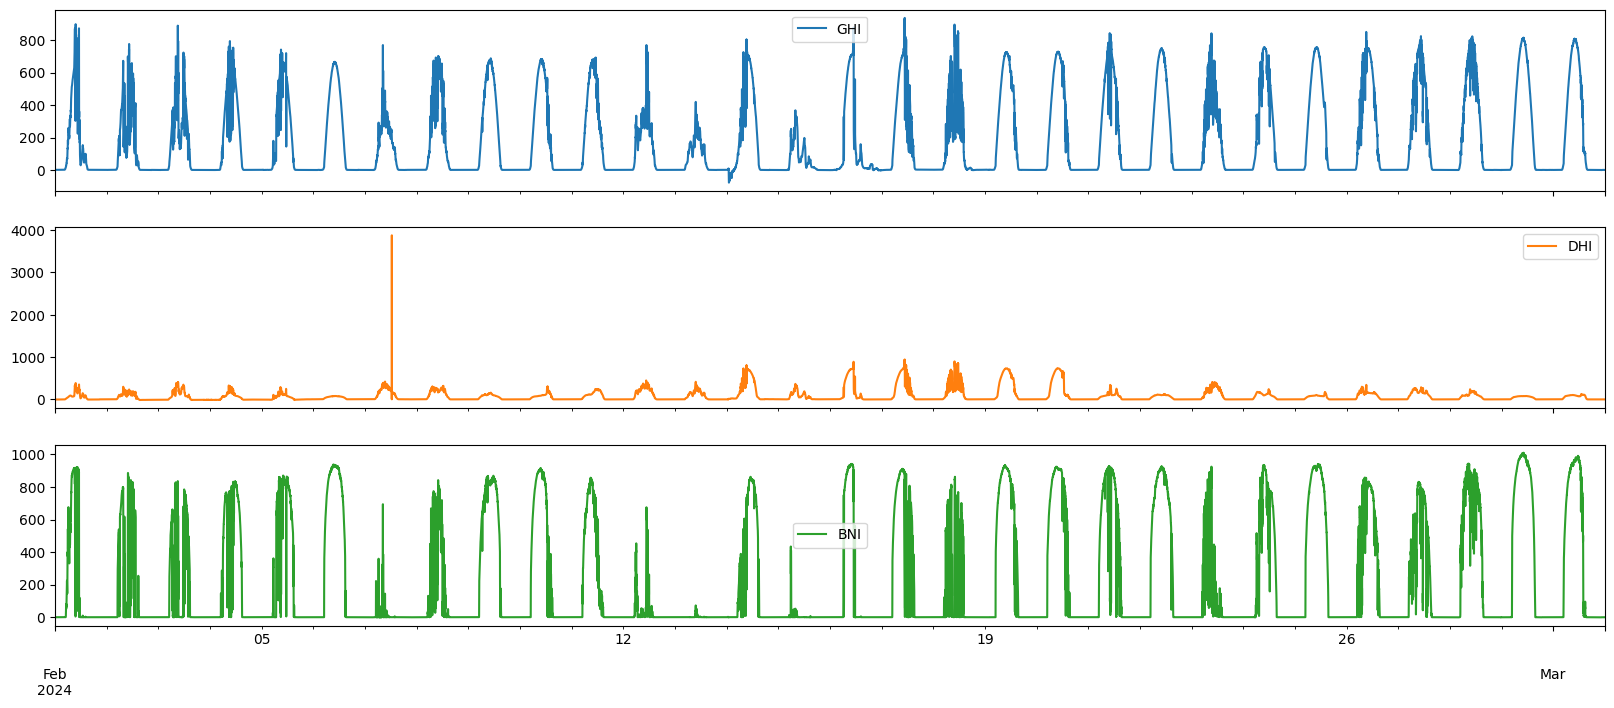

In [6]:
# Show one month of data
df["2024-02-01":"2024-03-01"].plot(figsize=(20, 8), subplots=True)

[17:25:24] ERROR    -:-     Image was not in cache and env var GOOGLE_API_KEY not set

[17:25:24] ERROR    -:-     Image was not in cache and env var GOOGLE_API_KEY not set

[17:25:24] ERROR    -:-     Image was not in cache and env var GOOGLE_API_KEY not set

/home/rjolivet/libinsitu/notebooks/../libinsitu/qc/graphs/base.py:980: UserWarning: Using the axes or figure transform requires a bounding box in the respective coordinates. Using bbox_to_anchor=(0, 0, 1, 1) now.
  cbaxes = inset_axes(


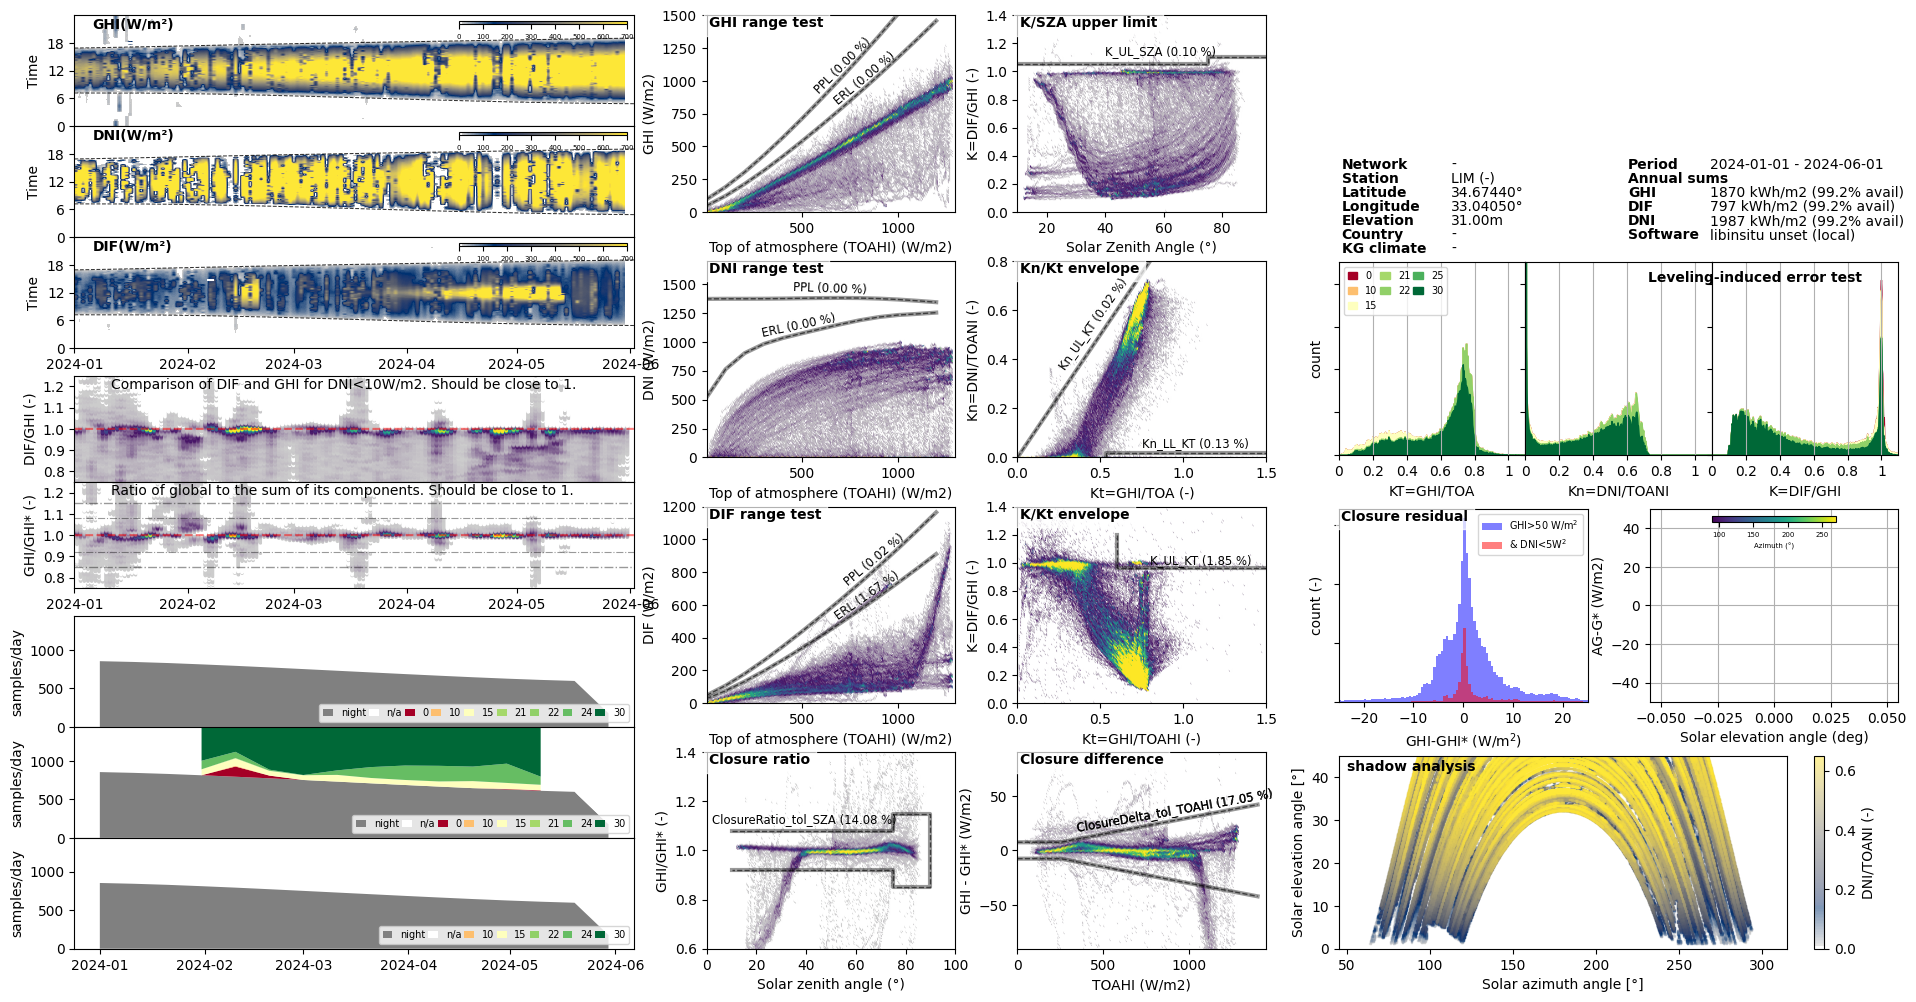

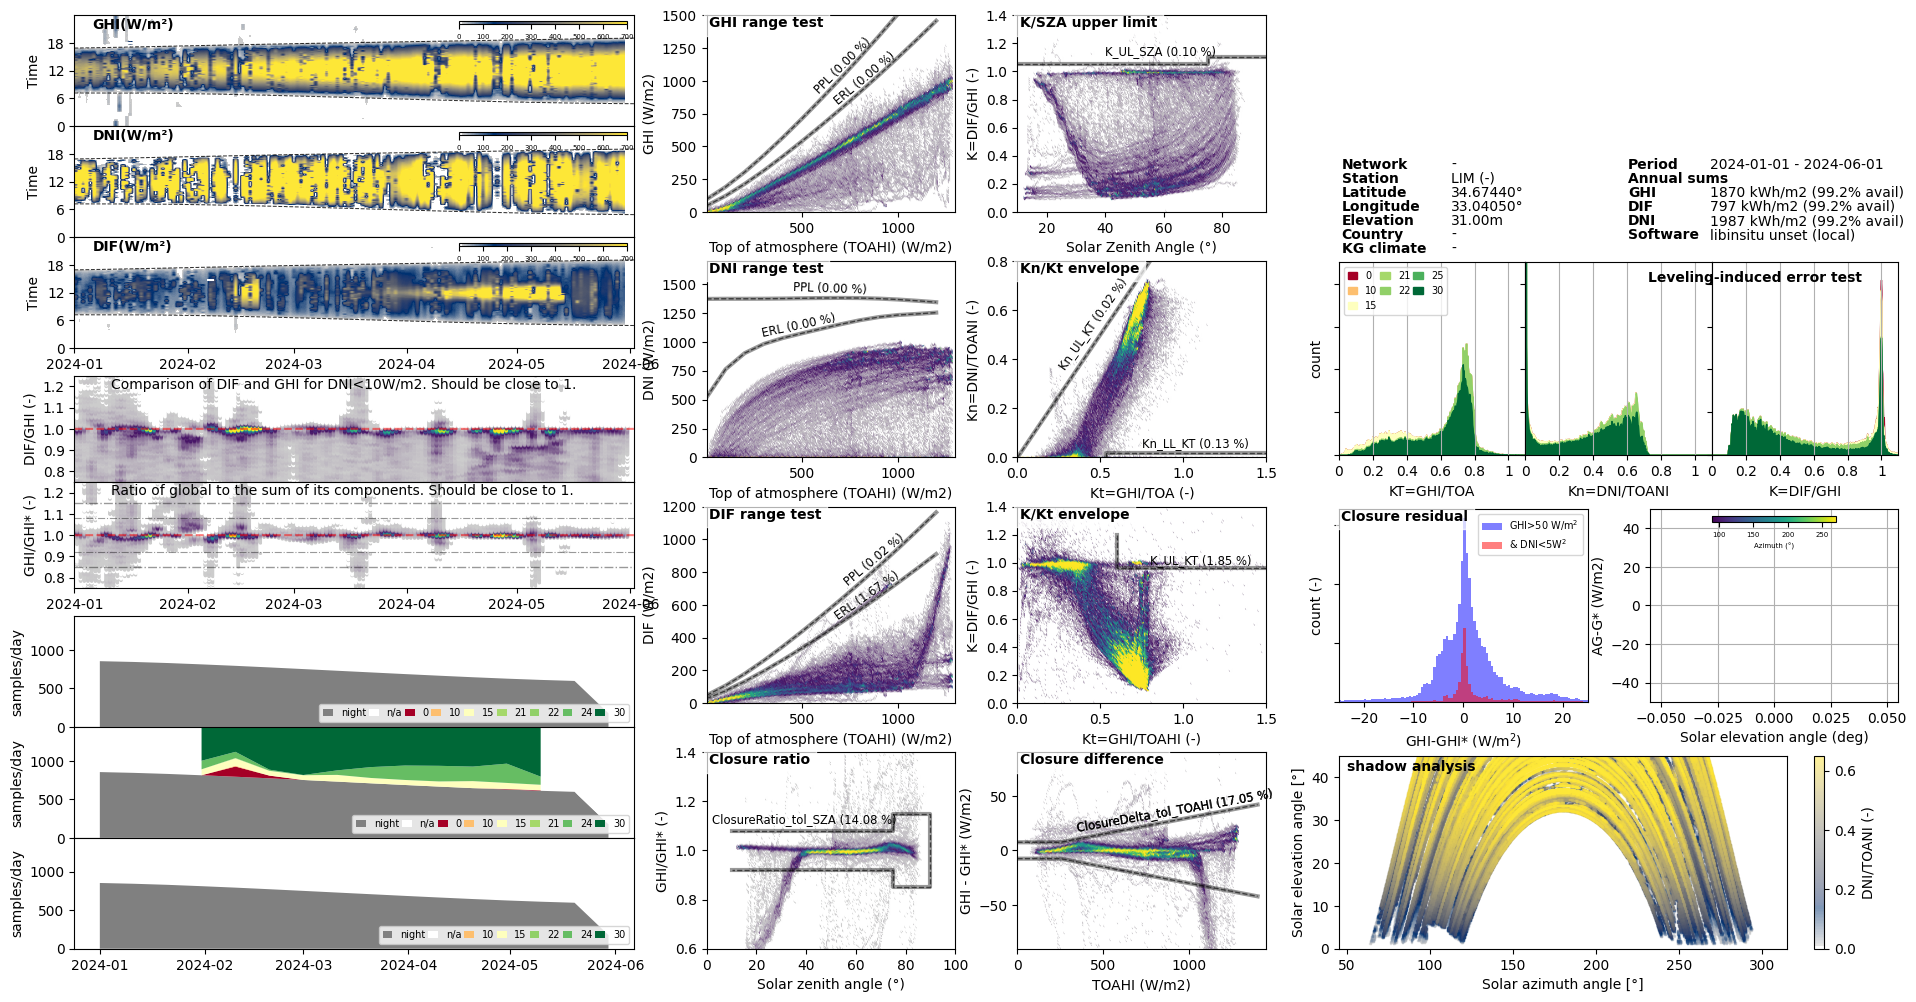

In [7]:
visual_qc(
    df,
    latitude=df.attrs["latitude"],
    longitude=df.attrs["longitude"],
    elevation=df.attrs["elevation"])